# Dr.Copper — Phase 3: GARCH Volatility modelling

In [34]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

import dr_copper as dc
from pathlib import Path

import warnings

warnings.filterwarnings("ignore")

FIGURES = Path("../outputs/figures")
DATA = Path("../data")

## 1 — Load Phase 1 outputs

In [2]:
raw_train = pd.read_parquet(DATA / "raw" / "raw_train.parquet")
raw_test = pd.read_parquet(DATA / "raw" / "raw_test.parquet")
raw = pd.read_parquet(DATA / "raw" / "raw.parquet")

features = pd.read_parquet(DATA / "processed" / "features.parquet")
features_train = pd.read_parquet(DATA / "processed" / "features_train.parquet")
features_test = pd.read_parquet(DATA / "processed" / "features_test.parquet")

In [3]:
price_train = raw_train["copper"].dropna()
price_test = raw_test["copper"].dropna()
price = raw["copper"].dropna()

log_ret = features["copper_ret1d"]
log_ret_train = features_train["copper_ret1d"]
log_ret_test = features_test["copper_ret1d"]

## 2 — ARIMA daily log returns with acf/pacf lags

In Phase 2, we observed that auto-arima with default limits p and q, and arima on monthly data give us far from satisfactory results.
That means we need a manual search for p and q via acf/pacf on daily data.

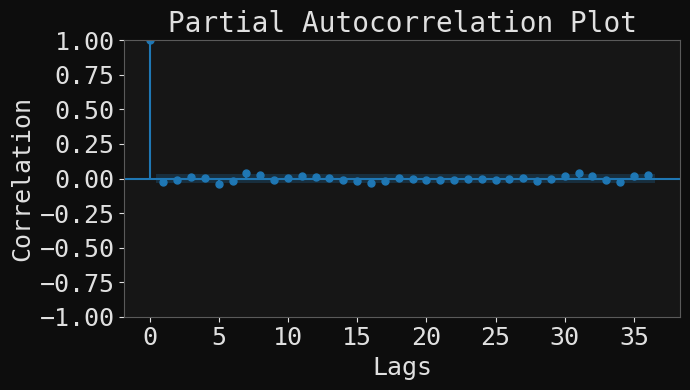

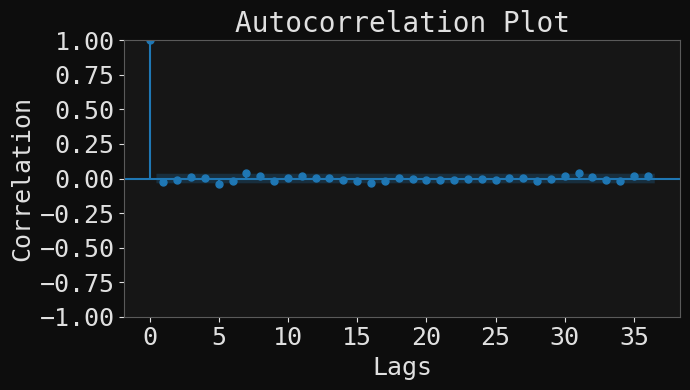

In [4]:
dc.pacf(log_ret_train)
dc.acf(log_ret_train)

In [5]:
pacf_df = dc.get_pacf(log_ret_train)

print("\n=== All significant PACF lags (any lag) ===")
print(pacf_df[pacf_df["significant"] & (pacf_df["lag"] > 0)].to_string())


=== All significant PACF lags (any lag) ===
     lag      pacf  ci_lower  ci_upper  significant
5      5 -0.041466 -0.034518  0.034518         True
7      7  0.038872 -0.034518  0.034518         True
31    31  0.036670 -0.034518  0.034518         True
38    38  0.041651 -0.034518  0.034518         True
40    40  0.034664 -0.034518  0.034518         True
79    79 -0.036884 -0.034518  0.034518         True
94    94  0.038169 -0.034518  0.034518         True
101  101  0.044088 -0.034518  0.034518         True
129  129 -0.034786 -0.034518  0.034518         True
145  145 -0.035302 -0.034518  0.034518         True
182  182  0.038677 -0.034518  0.034518         True
186  186 -0.048686 -0.034518  0.034518         True
189  189  0.035653 -0.034518  0.034518         True
191  191 -0.045130 -0.034518  0.034518         True
212  212  0.037426 -0.034518  0.034518         True


In [6]:
acf_df = dc.get_acf(log_ret_train)

print("\n=== All significant ACF lags (any lag) ===")
print(acf_df[acf_df["significant"] & (acf_df["lag"] > 0)].to_string())


=== All significant ACF lags (any lag) ===
     lag       acf  ci_lower  ci_upper  significant
5      5 -0.041871 -0.034545  0.034545         True
7      7  0.040406 -0.034616  0.034616         True
31    31  0.036391 -0.034817  0.034817         True
38    38  0.047370 -0.034915  0.034915         True
72    72 -0.036278 -0.035252  0.035252         True
86    86 -0.036326 -0.035422  0.035422         True
94    94  0.036869 -0.035499  0.035499         True
101  101  0.046711 -0.035574  0.035574         True
129  129 -0.038444 -0.035909  0.035909         True
130  130  0.036102 -0.035958  0.035958         True
135  135 -0.036070 -0.036052  0.036052         True
158  158  0.036726 -0.036285  0.036285         True
186  186 -0.055915 -0.036574  0.036574         True
189  189  0.037173 -0.036697  0.036697         True
191  191 -0.040446 -0.036742  0.036742         True
212  212  0.040319 -0.036922  0.036922         True


It's not rational to take all significant lags, so we are going to take reasonable ones, with stats much higher than ci and far apart from each other (as 5 - week, 21 - month(if it was significant))

In [7]:
p_lags = [5, 38, 101, 186]  # from PACF (AR structure)
q_lags = [5, 38, 101, 186]  # from ACF  (MA structure)

In [10]:
log_ret_train.index = pd.DatetimeIndex(log_ret_train.index)
log_ret_test.index = pd.DatetimeIndex(log_ret_test.index)

In [13]:
model_mdlr = ARIMA(log_ret_train, order=(p_lags, 0, q_lags)).fit()
forecasts_mdlr = model_mdlr.forecast(len(log_ret_test))

In [14]:
recovered_forecast_mdlr = dc.restore_prices(price_test, forecasts_mdlr)
recovered_train = dc.restore_prices(price_train, log_ret_train)
recovered_test = dc.restore_prices(price_test, log_ret_test)

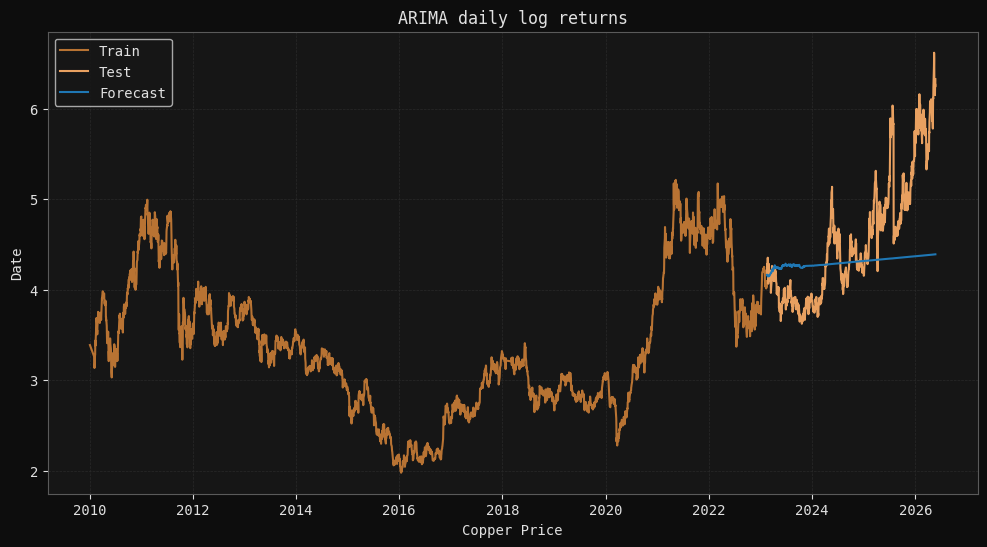

In [15]:
dc.plot_forecasts(
    recovered_train, recovered_test, recovered_forecast_mdlr, "ARIMA daily log returns"
)

In [16]:
dc.residuals_diagnostic(model_mdlr)

ARIMA([5, 38, 101, 186], 0, [5, 38, 101, 186]) Residual Diagnostics

Ljung-Box: No serial correlation in residuals
Jarque-Bera: p=0.0000  ⚠ Non-normal residuals — GARCH captures fat tails
Engle's ARCH LM test:  ⚠ ARCH effects present → GARCH justified



Now we have achieved what is desired: we removed correlations and retained ARCH effects. Fat tails signal us using dist='studentst' in the GARCH model.

## 3 — Walk-forward GARCH(1, 1)

We are going to use volatility as features for the next phases along all data set time, so to avoid leakage from ahead, we need to implement a walk-forward fit for the GARCH model.

In [17]:
log_ret_train.mean()

np.float64(5.4412901920511116e-05)

In [18]:
forecasts_mdlr.tail()

4026    0.00005
4027    0.00005
4028    0.00005
4029    0.00005
4030    0.00005
Name: predicted_mean, dtype: float64

ARIMA led to a constant log return, which is pretty close to the real mean value. So we can use a constant mean for the GARCH model.

In [19]:
garch_wf, model_garch = dc.walk_forward_garch(
    log_ret,
    min_train_size=252,
    refit_every=5,
    mean="Constant",
    p=1,
    q=1,
    dist="studentst",
    verbose=True,
)

  Walk-forward: t=252/4031  (6%)  train_size=252
  Walk-forward: t=302/4031  (7%)  train_size=302
  Walk-forward: t=352/4031  (9%)  train_size=352
  Walk-forward: t=402/4031  (10%)  train_size=402
  Walk-forward: t=452/4031  (11%)  train_size=452
  Walk-forward: t=502/4031  (12%)  train_size=502
  Walk-forward: t=552/4031  (14%)  train_size=552
  Walk-forward: t=602/4031  (15%)  train_size=602
  Walk-forward: t=652/4031  (16%)  train_size=652
  Walk-forward: t=702/4031  (17%)  train_size=702
  Walk-forward: t=752/4031  (19%)  train_size=752
  Walk-forward: t=802/4031  (20%)  train_size=802
  Walk-forward: t=852/4031  (21%)  train_size=852
  Walk-forward: t=902/4031  (22%)  train_size=902
  Walk-forward: t=952/4031  (24%)  train_size=952
  Walk-forward: t=1002/4031  (25%)  train_size=1002
  Walk-forward: t=1052/4031  (26%)  train_size=1052
  Walk-forward: t=1102/4031  (27%)  train_size=1102
  Walk-forward: t=1152/4031  (29%)  train_size=1152
  Walk-forward: t=1202/4031  (30%)  train_siz

In [20]:
print(garch_wf.describe())
garch_wf.tail()

       garch_cond_vol  garch_cond_var  garch_vol_ann        omega  \
count     3779.000000     3779.000000    3779.000000  3779.000000   
mean         0.014430        0.000224       0.229069     0.041938   
std          0.003930        0.000168       0.062394     0.047749   
min          0.008066        0.000065       0.128047     0.014463   
25%          0.011949        0.000143       0.189681     0.018839   
50%          0.013861        0.000192       0.220031     0.020951   
75%          0.015892        0.000253       0.252271     0.027319   
max          0.049990        0.002499       0.793564     0.220164   

             alpha         beta  persistence  
count  3779.000000  3779.000000  3779.000000  
mean      0.044991     0.938048     0.983039  
std       0.011582     0.026230     0.016124  
min       0.031718     0.835861     0.923482  
25%       0.036491     0.937122     0.987615  
50%       0.040865     0.948215     0.990150  
75%       0.048506     0.953963     0.991343  
ma

,garch_cond_vol,garch_cond_var,garch_vol_ann,omega,alpha,beta,persistence
date,,,,,,,
2026-05-18,0.016489,0.000272,0.261749,0.047052,0.045737,0.933083,0.978820
2026-05-19,0.018617,0.000347,0.295544,0.046573,0.045791,0.933411,0.979203
2026-05-20,0.018617,0.000347,0.295544,0.046573,0.045791,0.933411,0.979203
2026-05-21,0.018617,0.000347,0.295544,0.046573,0.045791,0.933411,0.979203
2026-05-22,0.018617,0.000347,0.295544,0.046573,0.045791,0.933411,0.979203


## 4 — Plot GARCH(1, 1)

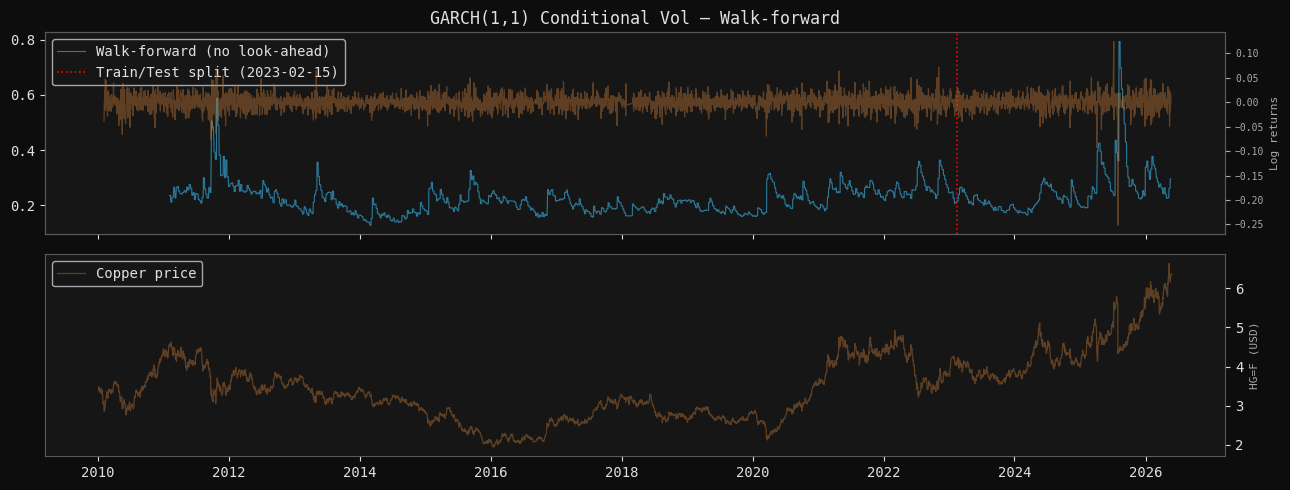

In [35]:
dc.plot_garch(
    price,
    log_ret,
    garch_wf,
    split_date=features_train.index[-1],
    save_path=FIGURES / "garch_result.png",
)

## 5 — Save GARCH results as features

In [30]:
features_with_vol = features.join(
    garch_wf[["garch_cond_vol", "garch_cond_var", "garch_vol_ann", "persistence"]],
    how="left",
)

## 6 — Save pipeline artefacts

In [33]:
import joblib

joblib.dump(model_mdlr, DATA / "processed" / "arima_mdlr.joblib")
joblib.dump(model_garch, DATA / "processed" / "garch.joblib")

garch_wf.to_parquet(DATA / "processed" / "garch_wf.parquet")
features_with_vol.to_parquet(DATA / "processed" / "features_with_vol.parquet")

A note: The arima model weights 20gb so instead of add it to git we add it to gitignore